# Stock Prediction using RNN


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

import torch
import torch.nn as nn

from torch.utils.data import DataLoader, TensorDataset


In [2]:
df_train = pd.read_csv('trainset.csv')
df_test = pd.read_csv('testset.csv')

print("Training Dataset Shape:", df_train.shape)
print("Testing Dataset Shape:", df_test.shape)

print("\nTraining Dataset:")
print(df_train.head())

print("\nTesting Dataset:")
print(df_test.head())


Training Dataset Shape: (1259, 7)
Testing Dataset Shape: (125, 7)

Training Dataset:
         Date        Open        High         Low       Close   Adj Close  \
0  2013-01-02  357.385559  361.151062  355.959839  359.288177  359.288177   
1  2013-01-03  360.122742  363.600128  358.031342  359.496826  359.496826   
2  2013-01-04  362.313507  368.339294  361.488861  366.600616  366.600616   
3  2013-01-07  365.348755  367.301056  362.929504  365.001007  365.001007   
4  2013-01-08  365.393463  365.771027  359.874359  364.280701  364.280701   

    Volume  
0  5115500  
1  4666500  
2  5562800  
3  3332900  
4  3373900  

Testing Dataset:
         Date         Open         High          Low        Close  \
0  2018-01-02  1048.339966  1066.939941  1045.229980  1065.000000   
1  2018-01-03  1064.310059  1086.290039  1063.209961  1082.479980   
2  2018-01-04  1088.000000  1093.569946  1084.001953  1086.400024   
3  2018-01-05  1094.000000  1104.250000  1092.000000  1102.229980   
4  2018-01-

In [3]:

train_prices = df_train['Close'].values.reshape(-1, 1)
test_prices = df_test['Close'].values.reshape(-1, 1)

print("\nTraining price shape:", train_prices.shape)
print("Testing price shape:", test_prices.shape)


Training price shape: (1259, 1)
Testing price shape: (125, 1)


In [4]:
scaler = MinMaxScaler()

scaled_train = scaler.fit_transform(train_prices)
scaled_test = scaler.transform(test_prices)

In [5]:
def create_sequences(data, seq_length):

    x = []
    y = []

    for i in range(len(data) - seq_length):

        x.append(data[i:i + seq_length])
        y.append(data[i + seq_length])

    return np.array(x), np.array(y)


# Number of previous days used to predict the next day
seq_length = 60


x_train, y_train = create_sequences(
    scaled_train,
    seq_length
)

x_test, y_test = create_sequences(
    scaled_test,
    seq_length
)


print("\nSequence Shapes:")
print("X_train:", x_train.shape)
print("Y_train:", y_train.shape)
print("X_test :", x_test.shape)
print("Y_test :", y_test.shape)



Sequence Shapes:
X_train: (1199, 60, 1)
Y_train: (1199, 1)
X_test : (65, 60, 1)
Y_test : (65, 1)


In [6]:
x_train_tensor = torch.tensor(
    x_train,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train,
    dtype=torch.float32
)

x_test_tensor = torch.tensor(
    x_test,
    dtype=torch.float32
)

y_test_tensor = torch.tensor(
    y_test,
    dtype=torch.float32
)

In [7]:
train_dataset = TensorDataset(
    x_train_tensor,
    y_train_tensor
)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

print("\nDataLoader created successfully!")




DataLoader created successfully!


In [8]:
class RNNModel(nn.Module):

    def __init__(
        self,
        input_size=1,
        hidden_size=64,
        num_layers=2,
        output_size=1
    ):

        super(RNNModel, self).__init__()

        # RNN layer
        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        # Fully connected output layer
        self.fc = nn.Linear(
            hidden_size,
            output_size
        )

    def forward(self, x):

        # RNN output
        out, hidden = self.rnn(x)

        # Take output from the last time step
        out = out[:, -1, :]

        # Fully connected layer
        out = self.fc(out)

        return out

In [9]:
model = RNNModel()

# Select GPU if available, otherwise CPU
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = model.to(device)

print("\nUsing device:", device)

print("\nRNN Model:")
print(model)


Using device: cpu

RNN Model:
RNNModel(
  (rnn): RNN(1, 64, num_layers=2, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


In [10]:
try:

    from torchinfo import summary

    summary(
        model,
        input_size=(64, 60, 1)
    )

except ImportError:

    print(
        "\nTorchinfo is not installed."
    )

    print(
        "Run: pip install torchinfo"
    )

In [11]:
criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)


In [12]:
num_epochs = 20

train_losses = []


for epoch in range(num_epochs):

    model.train()

    running_loss = 0.0

    for images, labels in train_loader:

        # Move data to selected device
        images = images.to(device)
        labels = labels.to(device)

        # ----------------------------------------------------
        # Forward pass
        # ----------------------------------------------------

        outputs = model(images)

        # Calculate loss
        loss = criterion(
            outputs,
            labels
        )

        # ----------------------------------------------------
        # Backward pass
        # ----------------------------------------------------

        optimizer.zero_grad()

        loss.backward()

        # Update weights
        optimizer.step()

        running_loss += loss.item()


    # Average loss for epoch
    epoch_loss = (
        running_loss /
        len(train_loader)
    )

    train_losses.append(epoch_loss)

    print(
        f"Epoch [{epoch + 1}/{num_epochs}], "
        f"Loss: {epoch_loss:.6f}"
    )


Epoch [1/20], Loss: 0.075144
Epoch [2/20], Loss: 0.022173
Epoch [3/20], Loss: 0.002012
Epoch [4/20], Loss: 0.000635
Epoch [5/20], Loss: 0.000448
Epoch [6/20], Loss: 0.000408
Epoch [7/20], Loss: 0.000379
Epoch [8/20], Loss: 0.000361
Epoch [9/20], Loss: 0.000342
Epoch [10/20], Loss: 0.000364
Epoch [11/20], Loss: 0.000353
Epoch [12/20], Loss: 0.000321
Epoch [13/20], Loss: 0.000323
Epoch [14/20], Loss: 0.000345
Epoch [15/20], Loss: 0.000313
Epoch [16/20], Loss: 0.000325
Epoch [17/20], Loss: 0.000341
Epoch [18/20], Loss: 0.000341
Epoch [19/20], Loss: 0.000304
Epoch [20/20], Loss: 0.000295



Name: Harini G
Register Number: 212225230091


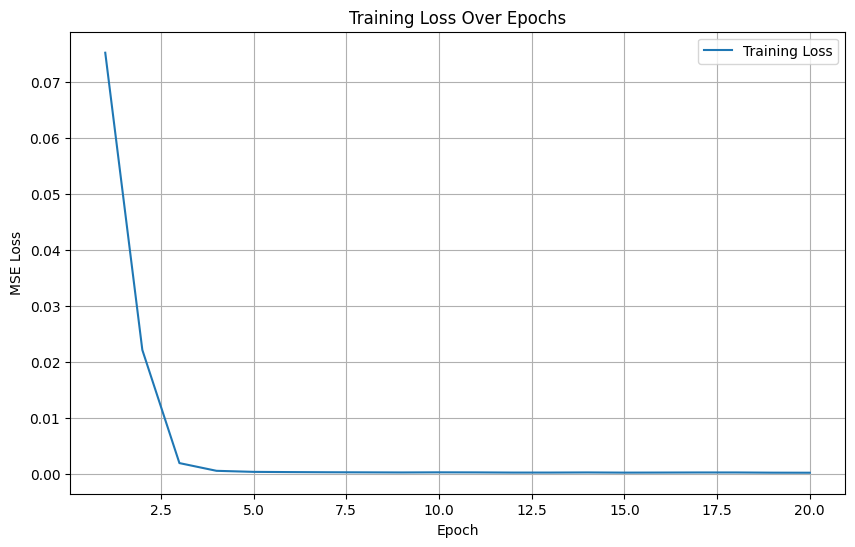

In [13]:
print("\nName: Harini G")
print("Register Number: 212225230091")

plt.figure(figsize=(10, 6))

plt.plot(
    range(1, num_epochs + 1),
    train_losses,
    label='Training Loss'
)

plt.xlabel('Epoch')
plt.ylabel('MSE Loss')

plt.title(
    'Training Loss Over Epochs'
)

plt.legend()

plt.grid(True)

plt.show()

In [14]:

model.eval()

with torch.no_grad():

    predicted = model(
        x_test_tensor.to(device)
    ).cpu().numpy()

    actual = (
        y_test_tensor
        .cpu()
        .numpy()
    )



In [15]:

predicted_prices = scaler.inverse_transform(
    predicted
)

actual_prices = scaler.inverse_transform(
    actual
)


In [16]:
test_mse = np.mean(
    (actual_prices - predicted_prices) ** 2
)

test_rmse = np.sqrt(test_mse)

print("\nTest MSE:", test_mse)

print("Test RMSE:", test_rmse)



Test MSE: 1067.1035
Test RMSE: 32.66655



Name: Harini G
Register Number: 212225230091


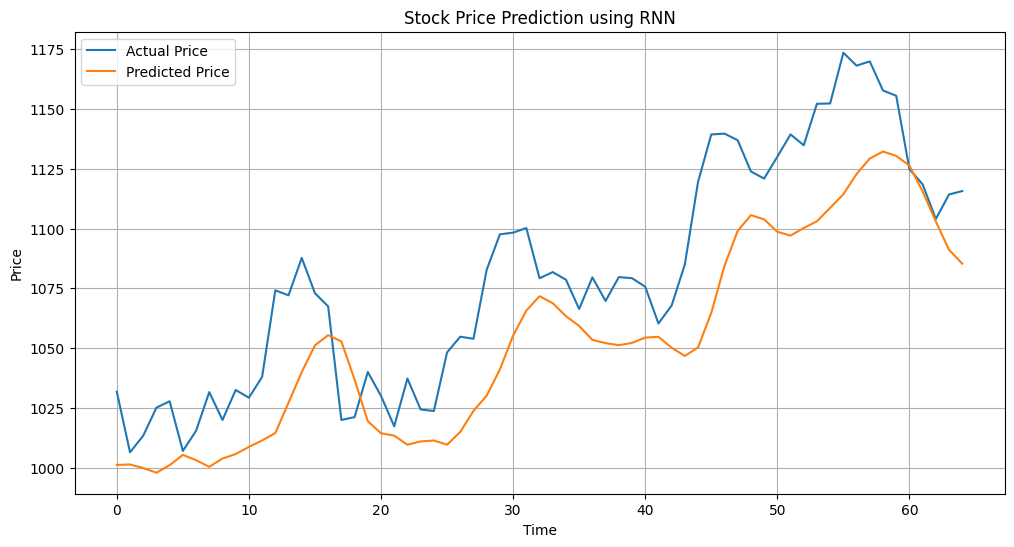

In [17]:
print("\nName: Harini G")
print("Register Number: 212225230091")

plt.figure(figsize=(12, 6))

plt.plot(
    actual_prices,
    label='Actual Price'
)

plt.plot(
    predicted_prices,
    label='Predicted Price'
)

plt.xlabel('Time')

plt.ylabel('Price')

plt.title(
    'Stock Price Prediction using RNN'
)

plt.legend()

plt.grid(True)

plt.show()

In [18]:

print("\n==========================================")
print("          FINAL PREDICTION RESULT")
print("==========================================")

print("Name: Harini G")

print(
    "Register Number: 212225230091"
)

print(
    f"Predicted Price: "
    f"{predicted_prices[-1][0]:.4f}"
)

print(
    f"Actual Price: "
    f"{actual_prices[-1][0]:.4f}"
)

print("==========================================")


          FINAL PREDICTION RESULT
Name: Harini G
Register Number: 212225230091
Predicted Price: 1085.3088
Actual Price: 1115.6500
